# Cluster Stories with K-Means

Goal: cluster the stories using text alone, then inspect whether the clusters show anything interesting related to author pronouns, genre/category, or represented gender.

- The algorithm groups stories based on similarity in word usage

## Text Representation 
TF-IDF (Term Frequency–Inverse Document Frequency):
- How often a word appears in a document
- How unique that word is across all documents


## Dimensionality Reduction (SVD)

TF-IDF produces a high-dimensional dataset, which can be noisy/inefficient for clustering.

SVD (Singular Value Decomposition):
- Reduce dimensionality
- Capture the most important patterns in word usage
- Improve clustering performance


In [72]:
import re
import zipfile
from pathlib import Path
from xml.etree import ElementTree as ET

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

from stop_words import stop_word_list

DATA_PATH = Path("data/compiled_stats.csv")
TEXT_DIR = Path("text/Texts")

RANDOM_STATE = 42
K = 5

In [73]:
import stop_words

vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stop_words.stop_word_list,
    max_features=10000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 3)
)

X_tfidf = vectorizer.fit_transform(story_df["text"])

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (610, 10000)


In [74]:
stats = pd.read_csv(DATA_PATH)

fiction = stats[stats["Type"] == "Original Fiction"].copy()

fiction["pronoun_clean"] = fiction["Pronoun"].str.lower().str.strip()
fiction["category_clean"] = fiction["Category"].fillna("Unknown")

print("Original fiction rows:", len(fiction))

fiction[["Title", "Author", "Pronoun", "Category"]].head()

Original fiction rows: 661


,Title,Author,Pronoun,Category
1,Down on the Farm,Charles Stross,He/him,Fantasy
2,After the Coup,John Scalzi,He/him,Science Fiction
4,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,NaN
5,Shade,Steven Gould,He/him,NaN
6,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Fantasy


In [75]:
def read_docx_text(path):
    paragraphs = []

    with zipfile.ZipFile(path) as docx_zip:
        xml = docx_zip.read("word/document.xml")

    root = ET.fromstring(xml)
    namespace = {"w": "http://schemas.openxmlformats.org/wordprocessingml/2006/main"}

    for paragraph in root.findall(".//w:p", namespace):
        text_parts = [
            node.text
            for node in paragraph.findall(".//w:t", namespace)
            if node.text
        ]
        if text_parts:
            paragraphs.append("".join(text_parts))

    return "\n".join(paragraphs)


def normalize_title(title):
    title = str(title).lower()
    title = re.sub(r"[^a-z0-9]+", " ", title)
    title = re.sub(r"\s+", " ", title).strip()
    return title


def parse_filename(path):
    match = re.match(r"^(\d+)\s*(.*)$", path.stem)

    if match:
        return int(match.group(1)), match.group(2).strip()

    return None, path.stem

In [76]:
rows = []

for path in sorted(TEXT_DIR.glob("*.docx")):
    file_id, file_title = parse_filename(path)

    rows.append({
        "filename": path.name,
        "file_id": file_id,
        "file_title": file_title,
        "title_clean": normalize_title(file_title),
        "text": read_docx_text(path),
    })

texts = pd.DataFrame(rows)

print("Loaded text files:", len(texts))

texts.head()

Loaded text files: 762


,filename,file_id,file_title,title_clean,text
0,002 Down on the Farm.docx,2,Down on the Farm,down on the farm,"Ah, the joy of summer: here in the south-east ..."
1,003 After the Coup.docx,3,After the Coup,after the coup,“How well can you take a punch?” asked Deputy ...
2,006 The Things That Make Me Weak and Strange G...,6,The Things That Make Me Weak and Strange Get E...,the things that make me weak and strange get e...,"’Cause it’s gonna be the future soon,And I won..."
3,007 Shade.docx,7,Shade,shade,Xareed had been waiting for the water truck fo...
4,008 The Girl Who Sang Rose Madder.docx,8,The Girl Who Sang Rose Madder,the girl who sang rose madder,A real backstage mostly resembles the opening ...


In [77]:
fiction["title_clean"] = fiction["Title"].map(normalize_title)

story_df = texts.merge(
    fiction,
    on="title_clean",
    how="inner"
)

print("Matched stories:", len(story_df))

story_df[["filename", "Title", "Author", "Pronoun", "Category"]].head()


Matched stories: 625


,filename,Title,Author,Pronoun,Category
0,002 Down on the Farm.docx,Down on the Farm,Charles Stross,He/him,Fantasy
1,003 After the Coup.docx,After the Coup,John Scalzi,He/him,Science Fiction
2,006 The Things That Make Me Weak and Strange G...,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,NaN
3,007 Shade.docx,Shade,Steven Gould,He/him,NaN
4,008 The Girl Who Sang Rose Madder.docx,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Fantasy


In [78]:
print("Stories before removing duplicates:", len(story_df))

story_df = story_df.drop_duplicates(
    subset=["Title", "Author"],
    keep="first"
).reset_index(drop=True)

print("Stories after removing duplicates:", len(story_df))

Stories before removing duplicates: 625
Stories after removing duplicates: 610


In [79]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    stop_words=stop_words.stop_word_list,
    max_features=10000,
    min_df=5,
    max_df=0.85
)

X_tfidf = vectorizer.fit_transform(story_df["text"])

print("TF-IDF shape:", X_tfidf.shape)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:412: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['articl', 'mon'] not in stop_words.
  warnings.warn(


TF-IDF shape: (610, 10000)


In [80]:
n_components = min(50, X_tfidf.shape[0] - 1, X_tfidf.shape[1] - 1)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=RANDOM_STATE
)

X_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_svd.shape)

SVD shape: (610, 50)


In [81]:
for k in range(2, 16):
    test_kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    test_labels = test_kmeans.fit_predict(X_svd)

    cluster_sizes = pd.Series(test_labels).value_counts().sort_index()
    smallest_cluster = cluster_sizes.min()

    print(f"k = {k}")
    print(cluster_sizes.to_string())
    print(f"Smallest cluster size: {smallest_cluster}")

    if smallest_cluster >= 5:
        print("Every cluster has at least 5 stories.")
    else:
        print("At least one cluster has fewer than 5 stories.")

    print()

k = 2
0     11
1    599
Smallest cluster size: 11
Every cluster has at least 5 stories.

k = 3
0    344
1    255
2     11
Smallest cluster size: 11
Every cluster has at least 5 stories.

k = 4
0    188
1    407
2     11
3      4
Smallest cluster size: 4
At least one cluster has fewer than 5 stories.

k = 5
0    283
1     11
2    199
3      7
4    110
Smallest cluster size: 7
Every cluster has at least 5 stories.

k = 6
0    268
1     11
2      4
3    316
4      7
5      4
Smallest cluster size: 4
At least one cluster has fewer than 5 stories.

k = 7
0     11
1    289
2      4
3      8
4      7
5    186
6    105
Smallest cluster size: 4
At least one cluster has fewer than 5 stories.

k = 8
0    236
1      4
2     45
3    299
4     11
5      4
6      7
7      4
Smallest cluster size: 4
At least one cluster has fewer than 5 stories.

k = 9
0    204
1      4
2     40
3    241
4     11
5      4
6      7
7      4
8     95
Smallest cluster size: 4
At least one cluster has fewer than 5 stories

In [82]:
kmeans = KMeans(
    n_clusters=K,
    random_state=RANDOM_STATE,
    n_init=20
)

story_df["cluster"] = kmeans.fit_predict(X_svd)

story_df["cluster"].value_counts().sort_index()


cluster
0    283
1     11
2    199
3      7
4    110
Name: count, dtype: int64

In [83]:
#top keywords per cluster
feature_names = vectorizer.get_feature_names_out()

for cluster_id in sorted(story_df["cluster"].unique()):
    cluster_mask = story_df["cluster"].to_numpy() == cluster_id
    cluster_tfidf = X_tfidf[cluster_mask]

    mean_tfidf = cluster_tfidf.mean(axis=0).A1
    top_indices = mean_tfidf.argsort()[::-1][:10]
    top_terms = feature_names[top_indices]

    print(f"Cluster {cluster_id}:")
    print(", ".join(top_terms))
    print()

Cluster 0:
looked, man, asked, night, door, turned, room, himself, felt, dead

Cluster 1:
ritter, toby, sir, freki, wolf, wizard, man, mongolian, father, director

Cluster 2:
looked, man, father, mother, felt, door, asked, turned, night, woman

Cluster 3:
jack, bleak, lens, anton, fucking, dome, magic, guile, trick, windmill

Cluster 4:
asks, mother, feel, mom, door, dad, takes, house, man, father



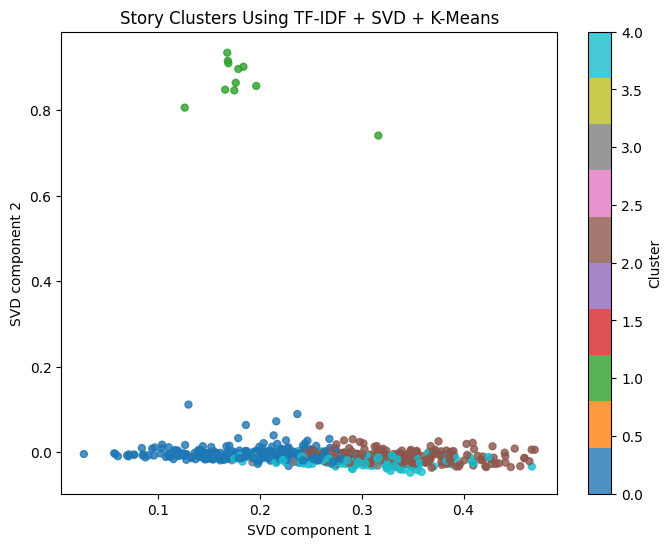

In [84]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_svd[:, 0],
    X_svd[:, 1],
    c=story_df["cluster"],
    cmap="tab10",
    s=25,
    alpha=0.8
)

plt.title("Story Clusters Using TF-IDF + SVD + K-Means")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.colorbar(label="Cluster")
plt.show()

In [85]:
pronoun_counts = pd.crosstab(
    story_df["cluster"],
    story_df["pronoun_clean"]
)

pronoun_percent = pd.crosstab(
    story_df["cluster"],
    story_df["pronoun_clean"],
    normalize="index"
).round(3)

display(pronoun_counts)
display(pronoun_percent)

pronoun_clean,he/him,she/her,they/them,ær/ærs
cluster,,,,
0,133,136,8,0
1,11,0,0,0
2,102,85,8,0
3,5,2,0,0
4,45,55,6,1


pronoun_clean,he/him,she/her,they/them,ær/ærs
cluster,,,,
0,0.480,0.491,0.029,0.000
1,1.000,0.000,0.000,0.000
2,0.523,0.436,0.041,0.000
3,0.714,0.286,0.000,0.000
4,0.421,0.514,0.056,0.009


In [86]:
category_counts = pd.crosstab(
    story_df["cluster"],
    story_df["category_clean"]
)

category_percent = pd.crosstab(
    story_df["cluster"],
    story_df["category_clean"],
    normalize="index"
).round(3)

display(category_counts)
display(category_percent)

category_clean,Alternate History,Apocalyptic and Post-Apocalyptic,Book Excerpt,Contemporary Fantasy,Cyberpunk,Dark Fantasy,Detective,Dystopian,Epic Fantasy,Fairy Tales and Folklore,...,Horror,Humor,Magical Realism,Military Science Fiction,Romantic,Science Fiction,Space Opera,Steampunk,Unknown,Urban Fantasy
cluster,,,,,,,,,,,,,,,,,,,,,
0,7,3,1,5,1,10,3,4,5,7,...,9,9,2,1,2,54,1,0,102,0
1,7,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,2,0
2,4,5,0,13,2,16,0,5,11,5,...,4,0,0,0,2,31,0,1,53,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,4,0
4,3,0,0,2,0,9,1,1,1,2,...,2,1,1,0,1,26,0,0,37,0


category_clean,Alternate History,Apocalyptic and Post-Apocalyptic,Book Excerpt,Contemporary Fantasy,Cyberpunk,Dark Fantasy,Detective,Dystopian,Epic Fantasy,Fairy Tales and Folklore,...,Horror,Humor,Magical Realism,Military Science Fiction,Romantic,Science Fiction,Space Opera,Steampunk,Unknown,Urban Fantasy
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.025,0.011,0.004,0.018,0.004,0.035,0.011,0.014,0.018,0.025,...,0.032,0.032,0.007,0.004,0.007,0.191,0.004,0.000,0.360,0.000
1,0.636,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.091,0.000,0.000,0.000,0.091,0.000,0.000,0.182,0.000
2,0.020,0.025,0.000,0.065,0.010,0.080,0.000,0.025,0.055,0.025,...,0.020,0.000,0.000,0.000,0.010,0.156,0.000,0.005,0.266,0.005
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.143,0.000,0.000,0.000,0.000,0.143,0.000,0.000,0.571,0.000
4,0.027,0.000,0.000,0.018,0.000,0.082,0.009,0.009,0.009,0.018,...,0.018,0.009,0.009,0.000,0.009,0.236,0.000,0.000,0.336,0.000


In [87]:
for cluster_id in sorted(story_df["cluster"].unique()):
    print(f"\nCluster {cluster_id}")

    display(
        story_df.loc[
            story_df["cluster"] == cluster_id,
            ["Title", "Author", "Pronoun", "Category"]
        ].head(10)
    )


Cluster 0


,Title,Author,Pronoun,Category
1,After the Coup,John Scalzi,He/him,Science Fiction
2,The Things That Make Me Weak and Strange Get E...,Cory Doctorow,He/him,NaN
5,Catch 'Em in the Act,Terry Bisson,He/him,Contemporary Fantasy
7,A Water Matter,Jay Lake,He/him,Epic Fantasy
8,Firstborn,Brandon Sanderson,He/him,Science Fiction
9,Errata,Jeff VanderMeer,He/him,Contemporary Fantasy
12,"Eros, Philia, Agape",Rachel Swirsky,She/her,Hard Science Fiction
13,We Haven't Got There Yet,Harry Turtledove,He/him,Science Fiction
16,Last Son of Tomorrow,Greg van Eekhout,He/him,Science Fiction
17,The House That George Built,Harry Turtledove,He/him,Alternate History



Cluster 1


,Title,Author,Pronoun,Category
111,The Mongolian Wizard,Michael Swanwick,He/him,Alternate History
116,The Fire Gown,Michael Swanwick,He/him,Alternate History
120,Day of the Kraken,Michael Swanwick,He/him,Alternate History
189,House of Dreams,Michael Swanwick,He/him,Alternate History
238,A Cost-Benefit Analysis of the Proposed Trade-...,John Chu,He/him,Science Fiction
294,The Night of the Salamander,Michael Swanwick,He/him,Alternate History
301,The Pyramid of Krakow,Michael Swanwick,He/him,Alternate History
308,The Phantom in the Maze,Michael Swanwick,He/him,Alternate History
314,Small Wars,Matt Wallace,He/him,Humor
461,Murder in the Spook House,Michael Swanwick,He/him,NaN



Cluster 2


,Title,Author,Pronoun,Category
3,Shade,Steven Gould,He/him,NaN
4,The Girl Who Sang Rose Madder,Elizabeth Bear,She/her,Fantasy
11,A Weeping Czar Beholds the Fallen Moon,Ken Scholes,He/him,Epic Fantasy
14,Bugs in the Arroyo,Steven Gould,He/him,Dystopian
15,TVA Baby,Terry Bisson,He/him,Contemporary Fantasy
19,The Nostalgist,Daniel H. Wilson,He/him,Science Fiction
20,The Ruined Queen of Harvest World,Damien Broderick,He/him,Fantasy
24,A Memory of Wind,Rachel Swirsky,She/her,Fairy Tales and Folklore
28,Farewell Performance,Nick Mamatas,He/him,Fantasy
37,Olga,C. T. Adams,She/her,Fantasy



Cluster 3


,Title,Author,Pronoun,Category
6,"Jack and the Aktuals, or, Physical Application...",Rudy Rucker,He/him,Science Fiction
83,Day One,Matthew Costello,He/him,Horror
123,King of Marbury,Andrew Smith,He/him,Fantasy
431,The Guile,Ian McDonald,He/him,NaN
514,For Every Jack,R. K. Duncan,He/him,NaN
570,"In Mercy, Rain",Seanan McGuire,She/her,NaN
603,On the Fox Roads,Nghi Vo,She/her,NaN



Cluster 4


,Title,Author,Pronoun,Category
0,Down on the Farm,Charles Stross,He/him,Fantasy
10,Escape to Other Worlds with Science Fiction,Jo Walton,She/her,Alternate History
27,Overtime,Charles Stross,He/him,Fantasy
32,The Next Invasion,Robert Reed,He/him,Science Fiction
46,The Monster's Million Faces,Rachel Swirsky,She/her,Science Fiction
61,Sweetheart,Abbey Mei Otis,She/her,Science Fiction
71,Ragnarok,Paul Park,He/him,Science Fiction
73,Crazy Me,James Patrick Kelly,He/him,Science Fiction
81,Swingers,Robert Reed,He/him,Humor
89,The Rotten Beast,Mary E. Pearson,She/her,Science Fiction


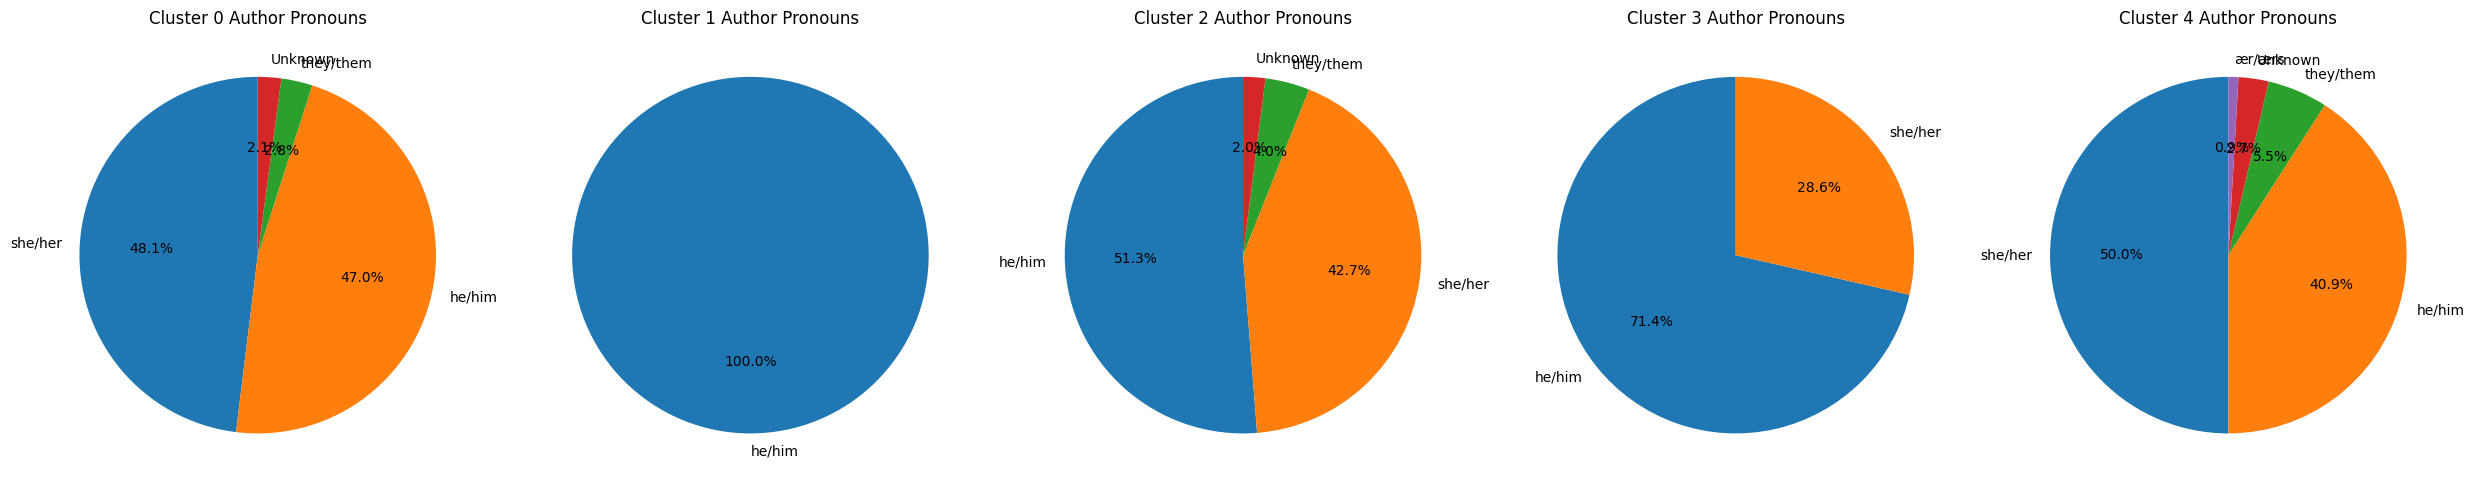

In [88]:
pronoun_column = "pronoun_clean"

clusters = sorted(story_df["cluster"].unique())

fig, axes = plt.subplots(
    1,
    len(clusters),
    figsize=(5 * len(clusters), 5)
)

if len(clusters) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, clusters):
    pronoun_counts = (
        story_df.loc[story_df["cluster"] == cluster_id, pronoun_column]
        .fillna("Unknown")
        .value_counts()
    )

    ax.pie(
        pronoun_counts,
        labels=pronoun_counts.index,
        autopct="%1.1f%%",
        startangle=90
    )

    ax.set_title(f"Cluster {cluster_id} Author Pronouns")

plt.tight_layout()
plt.show()